# CAVAS — Deep Learning Model Evaluation
### IDS Intrusion Detection: TabNet (Tabular) + TFT (Time Series)

**Dual prediction targets:**
- `label_generic` → Binary classification (benign / malicious)
- `Label` → Multiclass classification (benign / attack type)

**Models:**
- **TabNet** — sequential attention, native feature importance
- **Temporal Fusion Transformer (TFT)** — variable selection networks + temporal attention

**Hyperparameter tuning:** Optuna (TPE sampler)

---

### Notebook Workflow (5 steps)
1. **HPO (0.1% dataset):** Optuna hyperparameter search for TabNet & TFT — save all trial models + confusion matrices
2. **Best models & Feature Importance:** Extract best trial per model, plot feature importance
3. **Top features intersection:** Top-10 features from each model → intersection (~8–10 features)
4. **10% dataset (reduced features):** Stratified 10% sample, keep only important features
5. **Baseline training:** Retrain both models on the 10% reduced-feature dataset with optimized hyperparams

In [1]:
LOCAL_RUN = True
RANDOM_SEED = 42
RUNNINNG_ON_LINIX = True

## 0. Configuration & Setup

In [2]:
!pip install -q pytorch-tabnet pytorch-forecasting pytorch-lightning optuna optuna-integration scikit-learn pandas pyarrow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import os, subprocess, warnings, json
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# Spark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col
from pyspark.ml.feature import StringIndexer

# Sklearn
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.metrics          import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, matthews_corrcoef
)

# TabNet — multi-task classifier (predicts both targets simultaneously)
from pytorch_tabnet.multitask import TabNetMultiTaskClassifier

# TFT — use lightning.pytorch (NOT pytorch_lightning) to match pytorch_forecasting
import torch
import lightning.pytorch as pl
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data    import GroupNormalizer
from pytorch_forecasting.metrics import CrossEntropy, MultiLoss
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

# Optuna
import optuna
from optuna.integration import PyTorchLightningPruningCallback
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
pl.seed_everything(RANDOM_SEED)
print("All imports OK")

/home/cava/Documents/Repos/python/pucktrick/.venv/lib/python3.10/site-packages/pytorch_forecasting/models/base/_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
Seed set to 42


All imports OK


In [4]:
# ─────────────────────────────────────────────────────────────────────
# CONFIGURATION — change only here
# ─────────────────────────────────────────────────────────────────────
PATH_IMG = "images"

if LOCAL_RUN:
    PATH = "DATASETS"
    PERCENTAGE_TO_USE = 0.001
    N_OPTUNA_TRIALS   = 10           # 10 trials locally
    TABNET_MAX_EPOCHS = 50
    TFT_MAX_EPOCHS    = 30
else:
    PATH = "file:///home/PuckTrickadmin/DATASETS"
    PERCENTAGE_TO_USE = 1.0
    N_OPTUNA_TRIALS   = 20
    TABNET_MAX_EPOCHS = 150
    TFT_MAX_EPOCHS    = 100

RANDOM_SEED  = 42
TEST_SIZE    = 0.2
VAL_SIZE     = 0.1

os.makedirs(PATH_IMG, exist_ok=True)
os.makedirs("models",  exist_ok=True)

In [5]:
import os, subprocess

# Verifica JAVA_HOME
jh = os.environ.get('JAVA_HOME', 'NON IMPOSTATO')
print(f"JAVA_HOME = {jh}")
java_exe = os.path.join(jh, 'bin', 'java.exe')
print(f"java.exe esiste: {os.path.isfile(java_exe)}")

# Verifica versione
if os.path.isfile(java_exe):
    result = subprocess.run([java_exe, '-version'], capture_output=True, text=True)
    print(result.stderr)

# Verifica HADOOP_HOME
hh = os.environ.get('HADOOP_HOME', 'NON IMPOSTATO')
print(f"HADOOP_HOME = {hh}")

# Verifica PySpark version
import pyspark
print(f"PySpark version = {pyspark.__version__}")

JAVA_HOME = NON IMPOSTATO
java.exe esiste: False
HADOOP_HOME = NON IMPOSTATO
PySpark version = 3.5.0


In [6]:
# ── Spark session (LOCAL / SERVER) ──────────────────────────────────
if LOCAL_RUN:
    if (RUNNINNG_ON_LINIX):
        java_home = os.environ.get('JAVA_HOME', '')
        if not java_home:
            try:
                java_path = subprocess.check_output(['which', 'java'], text=True).strip()
                os.environ['JAVA_HOME'] = os.path.dirname(os.path.dirname(os.path.realpath(java_path)))
            except subprocess.CalledProcessError:
                print("⚠️  Java not found — run: sudo apt install default-jdk")

        os.environ['PYSPARK_PYTHON']        = 'python3'
        os.environ['PYSPARK_DRIVER_PYTHON'] = 'python3'

        spark = SparkSession.builder \
            .appName("CAVAS_Models") \
            .master("local[*]") \
            .config("spark.driver.memory",          "24g") \
            .config("spark.driver.host",            "localhost") \
            .config("spark.ui.showConsoleProgress", "false") \
            .getOrCreate()
        
    else:
        # Forza JAVA_HOME al JRE corretto
        os.environ['JAVA_HOME'] = r"C:\Program Files\Java\jre-1.8"

        # Hadoop winutils per Windows
        os.environ['HADOOP_HOME'] = r"C:\hadoop"
        os.environ['PATH'] = os.environ.get('PATH', '') + r';C:\hadoop\bin'

        # Su Windows l'eseguibile è 'python', non 'python3'
        py = 'python' if os.name == 'nt' else 'python3'
        os.environ['PYSPARK_PYTHON']        = py
        os.environ['PYSPARK_DRIVER_PYTHON'] = py

        spark = SparkSession.builder \
            .appName("CAVAS_Models") \
            .master("local[*]") \
            .config("spark.driver.memory",          "24g") \
            .config("spark.driver.host",            "localhost") \
            .config("spark.ui.showConsoleProgress", "false") \
            .getOrCreate()
        
else:
    MASTER_URL  = "spark://10.0.1.8:7077"
    DRIVER_HOST = "10.0.1.8"

    spark = SparkSession.builder \
        .appName("CAVAS_Models") \
        .master(MASTER_URL) \
        .config("spark.submit.deployMode",      "client") \
        .config("spark.executor.instances",     "4") \
        .config("spark.executor.cores",         "4") \
        .config("spark.executor.memory",        "13g") \
        .config("spark.driver.memory",          "8g") \
        .config("spark.driver.host",            DRIVER_HOST) \
        .config("spark.driver.bindAddress",     DRIVER_HOST) \
        .config("spark.sql.shuffle.partitions", "32") \
        .getOrCreate()
    spark.sparkContext.setLogLevel("WARN")

print(f"✅  Spark {spark.version} ready")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/05 22:33:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅  Spark 3.5.0 ready


## 1. Data Loading

In [7]:
# ── Load parquet ─────────────────────────────────────────────────────
sdf_full = spark.read.parquet(f'{PATH}/all_elaborated.parquet')

if PERCENTAGE_TO_USE < 1.0:
    # Stratified sampling per label_generic (la label binaria, più semplice da stratificare)
    # Calcola la fraction per ogni strato e campiona separatamente, poi unisce
    fractions = {
        row['label_generic']: PERCENTAGE_TO_USE
        for row in sdf_full.select('label_generic').distinct().collect()
    }
    sdf = sdf_full.sampleBy('label_generic', fractions=fractions, seed=RANDOM_SEED)
    print(f"📦  Stratified {PERCENTAGE_TO_USE*100:.0f}% sample → {sdf.count():,} rows")
else:
    sdf = sdf_full
    print(f"📦  Full dataset → {sdf.count():,} rows")

print(f"🧮  Columns: {len(sdf.columns)}")
sdf.printSchema()

FEATURE_NAMES = list(sdf.columns)

📦  Stratified 0% sample → 16,191 rows
🧮  Columns: 38
root
 |-- Dst Port: double (nullable = true)
 |-- Protocol: double (nullable = true)
 |-- Timestamp: string (nullable = true)
 |-- Flow Duration: double (nullable = true)
 |-- Tot Fwd Pkts: double (nullable = true)
 |-- Tot Bwd Pkts: double (nullable = true)
 |-- TotLen Fwd Pkts: double (nullable = true)
 |-- Fwd Pkt Len Max: double (nullable = true)
 |-- Fwd Pkt Len Min: double (nullable = true)
 |-- Bwd Pkt Len Max: double (nullable = true)
 |-- Bwd Pkt Len Min: double (nullable = true)
 |-- Bwd Pkt Len Mean: double (nullable = true)
 |-- Flow Byts/s: double (nullable = true)
 |-- Flow Pkts/s: double (nullable = true)
 |-- Flow IAT Mean: double (nullable = true)
 |-- Flow IAT Std: double (nullable = true)
 |-- Bwd IAT Tot: double (nullable = true)
 |-- Bwd IAT Mean: double (nullable = true)
 |-- Bwd IAT Std: double (nullable = true)
 |-- Fwd PSH Flags: double (nullable = true)
 |-- Fwd URG Flags: double (nullable = true)
 |-- Fwd P

## 2. Preprocessing — Normalization & Encoding

In [8]:
# ── Feature metadata from analysis ──────────────────────────────────
# Features ordered by relevance from your CSV exports

# Feature types from your analysis
CATEGORICAL_FEATURES = ['Fwd Seg Size Min', 'Protocol']
BINARY_FEATURES      = ['FIN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'Fwd URG Flag', 'Fwd PSH Flag']

# All features used for modelling
ALL_FEATURES = sdf_full.columns

# ✅ corretto
EXCLUDE_FROM_FEATURES = {'Label', 'label_generic', 'Timestamp'}

ALL_FEATURES = [c for c in sdf_full.columns if c not in EXCLUDE_FROM_FEATURES]

CONTINUOUS_FEATURES = [
    f for f in ALL_FEATURES
    if f not in CATEGORICAL_FEATURES and f not in BINARY_FEATURES
]

# Verify all expected features exist in the dataset
available = set(sdf.columns)
missing   = [f for f in ALL_FEATURES if f not in available]
if missing:
    print(f"⚠️  Missing features in dataset: {missing}")
    ALL_FEATURES = [f for f in ALL_FEATURES if f not in missing]
else:
    print(f"✅  All {len(ALL_FEATURES)} features found in dataset")

✅  All 35 features found in dataset


In [9]:
def label_encoding_spark(sdf):
    """Add label_generic_enc (0/1) and Label_enc (integer) to the Spark DataFrame.
    Returns (sdf_encoded, label_classes) where label_classes maps index → Label name.
    """
    # ── Binary: label_generic is already 0/1 → cast to int ──────────
    sdf = sdf.withColumn('label_generic_enc', col('label_generic').cast('int'))

    # ── Multiclass: Label → integer index via StringIndexer ──────────
    indexer = StringIndexer(inputCol='Label', outputCol='Label_enc', handleInvalid='keep')
    model = indexer.fit(sdf)
    sdf = model.transform(sdf)
    sdf = sdf.withColumn('Label_enc', col('Label_enc').cast('int'))

    # Store ordered label list: index 0 → labels[0], etc.
    label_classes = list(model.labels)

    n_binary = sdf.select('label_generic_enc').distinct().count()
    print(f"✅  label_generic_enc: {n_binary} classes | Label_enc: {len(label_classes)} classes")
    print(f"    Label mapping: { {i: l for i, l in enumerate(label_classes)} }")
    return sdf, label_classes

In [10]:
def preprocess_to_pandas(sdf, continuous_features, categorical_features, binary_features):
    """
    Convert Spark → Pandas and clean dtypes.
    
    - Continuous: cast to float64 (scaling done AFTER train/test split to avoid leakage)
    - Categorical: integer-encoded via LabelEncoder (TabNet/TFT handle them natively)
    - Binary: cast to int
    
    ⚠ NO one-hot encoding:
      • TabNet uses cat_idxs / cat_dims natively
      • TFT uses time_varying_known_categoricals
      • Feature importance stays traceable to the original feature name
    """
    print("⏳  Converting Spark → Pandas ...")
    pdf = sdf.toPandas()
    print(f"📊  Shape: {pdf.shape}")

    available = set(pdf.columns)
    cont_cols = [c for c in continuous_features if c in available]
    cat_cols  = [c for c in categorical_features if c in available]
    bin_cols  = [c for c in binary_features if c in available]

    # ── Continuous → float64 ──────────────────────────────────────────
    for c in cont_cols:
        pdf[c] = pd.to_numeric(pdf[c], errors='coerce')
    pdf[cont_cols] = pdf[cont_cols].fillna(0.0)

    # ── Categorical → integer codes ──────────────────────────────────
    cat_encoders = {}
    cat_dims = {}
    for c in cat_cols:
        le = LabelEncoder()
        pdf[c] = le.fit_transform(pdf[c].astype(str))
        cat_encoders[c] = le
        cat_dims[c] = len(le.classes_)

    # ── Binary → int ─────────────────────────────────────────────────
    for c in bin_cols:
        pdf[c] = pd.to_numeric(pdf[c], errors='coerce').fillna(0).astype(int)

    print(f"✅  Preprocessed: {len(cont_cols)} continuous | {len(cat_cols)} categorical | {len(bin_cols)} binary")
    return pdf, cat_encoders, cat_dims

In [11]:
# ── Preprocess & cache (Pandas-based, fast) ──────────────────────────
PREPROCESSED_PATH = f"{PATH}/preprocessed_model_{int(PERCENTAGE_TO_USE*100)}pct.parquet"

if os.path.exists(PREPROCESSED_PATH):
    pdf_encoded = pd.read_parquet(PREPROCESSED_PATH)

    # Rebuild metadata from cached file
    EXCLUDE = {'Label', 'label_generic', 'Label_enc', 'label_generic_enc', 'Timestamp'}
    FINAL_FEATURES = [c for c in pdf_encoded.columns if c not in EXCLUDE]

    # Recover label_classes mapping from data
    _lbl_map = (pdf_encoded[['Label', 'Label_enc']]
                .drop_duplicates()
                .sort_values('Label_enc')
                .set_index('Label_enc')['Label']
                .to_dict())
    label_classes = [_lbl_map[i] for i in range(len(_lbl_map))]

    # Categorical metadata for TabNet
    CAT_FEATURE_NAMES = [c for c in CATEGORICAL_FEATURES if c in FINAL_FEATURES]
    CAT_IDXS = [FINAL_FEATURES.index(c) for c in CAT_FEATURE_NAMES]
    CAT_DIMS = [int(pdf_encoded[c].nunique()) for c in CAT_FEATURE_NAMES]

    print(f"✅  Cache loaded: {len(pdf_encoded):,} rows, {len(FINAL_FEATURES)} features")
else:
    print("⚠️  No cache found — running preprocessing ...")
    sdf_enc, label_classes = label_encoding_spark(sdf)
    pdf_encoded, cat_encoders, cat_dims_dict = preprocess_to_pandas(
        sdf_enc, CONTINUOUS_FEATURES, CATEGORICAL_FEATURES, BINARY_FEATURES
    )

    EXCLUDE = {'Label', 'label_generic', 'Label_enc', 'label_generic_enc', 'Timestamp'}
    FINAL_FEATURES = [c for c in pdf_encoded.columns if c not in EXCLUDE]
    CAT_FEATURE_NAMES = [c for c in CATEGORICAL_FEATURES if c in FINAL_FEATURES]
    CAT_IDXS = [FINAL_FEATURES.index(c) for c in CAT_FEATURE_NAMES]
    CAT_DIMS = [cat_dims_dict[c] for c in CAT_FEATURE_NAMES]

    pdf_encoded.to_parquet(PREPROCESSED_PATH, index=False)
    print(f"💾  Saved to {PREPROCESSED_PATH}")

# ── Global counters ──────────────────────────────────────────────────
n_classes_multi = len(label_classes)

print(f"\n🧮  Features: {len(FINAL_FEATURES)} | Binary classes: 2 | Multi classes: {n_classes_multi}")
print(f"📌  Label mapping: { {i: l for i, l in enumerate(label_classes)} }")
if CAT_IDXS:
    print(f"📌  Categorical for TabNet: {list(zip(CAT_FEATURE_NAMES, CAT_IDXS, CAT_DIMS))}")
else:
    print("📌  No categorical features detected in final feature set")

✅  Cache loaded: 16,191 rows, 35 features

🧮  Features: 35 | Binary classes: 2 | Multi classes: 12
📌  Label mapping: {0: 'Benign', 1: 'DDOS attack-HOIC', 2: 'DDoS attacks-LOIC-HTTP', 3: 'DoS attacks-Hulk', 4: 'Bot', 5: 'SSH-Bruteforce', 6: 'FTP-BruteForce', 7: 'Infilteration', 8: 'DoS attacks-SlowHTTPTest', 9: 'DoS attacks-GoldenEye', 10: 'DoS attacks-Slowloris', 11: 'DDOS attack-LOIC-UDP'}
📌  Categorical for TabNet: [('Fwd Seg Size Min', 31, 9), ('Protocol', 1, 3)]


In [12]:
# ── Diagnostica: cosa c'è davvero nel dataframe? ─────────────────────
print("\nTutte le colonne nel pdf_encoded:")
for i, c in enumerate(pdf_encoded.columns):
    is_in_exclude = c in EXCLUDE
    is_in_final = c in FINAL_FEATURES
    print(f"  {i:2d}. '{c}' → EXCLUDE={is_in_exclude}, FINAL={is_in_final}")

print(f"\nTotal columns: {len(pdf_encoded.columns)}")
print(f"FINAL_FEATURES: {len(FINAL_FEATURES)}")
print(f"EXCLUDE matches: {[c for c in pdf_encoded.columns if c in EXCLUDE]}")
print(f"NOT excluded but look like targets: {[c for c in FINAL_FEATURES if 'label' in c.lower() or 'Label' in c]}")


Tutte le colonne nel pdf_encoded:
   0. 'Dst Port' → EXCLUDE=False, FINAL=True
   1. 'Protocol' → EXCLUDE=False, FINAL=True
   2. 'Timestamp' → EXCLUDE=True, FINAL=False
   3. 'Flow Duration' → EXCLUDE=False, FINAL=True
   4. 'Tot Fwd Pkts' → EXCLUDE=False, FINAL=True
   5. 'Tot Bwd Pkts' → EXCLUDE=False, FINAL=True
   6. 'TotLen Fwd Pkts' → EXCLUDE=False, FINAL=True
   7. 'Fwd Pkt Len Max' → EXCLUDE=False, FINAL=True
   8. 'Fwd Pkt Len Min' → EXCLUDE=False, FINAL=True
   9. 'Bwd Pkt Len Max' → EXCLUDE=False, FINAL=True
  10. 'Bwd Pkt Len Min' → EXCLUDE=False, FINAL=True
  11. 'Bwd Pkt Len Mean' → EXCLUDE=False, FINAL=True
  12. 'Flow Byts/s' → EXCLUDE=False, FINAL=True
  13. 'Flow Pkts/s' → EXCLUDE=False, FINAL=True
  14. 'Flow IAT Mean' → EXCLUDE=False, FINAL=True
  15. 'Flow IAT Std' → EXCLUDE=False, FINAL=True
  16. 'Bwd IAT Tot' → EXCLUDE=False, FINAL=True
  17. 'Bwd IAT Mean' → EXCLUDE=False, FINAL=True
  18. 'Bwd IAT Std' → EXCLUDE=False, FINAL=True
  19. 'Fwd PSH Flags' → EXCL

### 2.1 Prepare arrays for modelling

In [13]:
# ── Data is already in Pandas from preprocessing ─────────────────────
X = pdf_encoded[FINAL_FEATURES].values.astype(np.float64)  # float64 first to detect issues
y_binary = pdf_encoded['label_generic_enc'].values.astype(int)
y_multi  = pdf_encoded['Label_enc'].values.astype(int)

# ── Clean inf / extreme values ───────────────────────────────────────
n_inf = np.isinf(X).sum()
n_nan = np.isnan(X).sum()
if n_inf > 0 or n_nan > 0:
    print(f"⚠️  Found {n_inf} inf and {n_nan} NaN values → replacing with 0")
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Clip extreme outliers that overflow float32 range
f32_max = np.finfo(np.float32).max
n_clipped = (np.abs(X) > f32_max).sum()
if n_clipped > 0:
    print(f"⚠️  Clipping {n_clipped} values exceeding float32 range")
    X = np.clip(X, -f32_max, f32_max)

X = X.astype(np.float32)

print(f"📊  X shape: {X.shape}")
print(f"    y_binary: {np.unique(y_binary, return_counts=True)}")
print(f"    y_multi:  {len(np.unique(y_multi))} classes (n_classes_multi={n_classes_multi})")

📊  X shape: (16191, 35)
    y_binary: (array([0, 1]), array([13433,  2758]))
    y_multi:  12 classes (n_classes_multi=12)


In [14]:
# ── Unified split — BOTH targets on the same row subset ──────────────
# Multi-task learning requires identical samples for both heads.
# We filter rare multiclass labels first, then do a SINGLE split.

MIN_SAMPLES_PER_CLASS = 5

classes, counts = np.unique(y_multi, return_counts=True)
rare_classes    = classes[counts < MIN_SAMPLES_PER_CLASS]

if len(rare_classes) > 0:
    rare_labels = [label_classes[c] for c in rare_classes]
    print(f"⚠️  Dropping {len(rare_classes)} rare classes (< {MIN_SAMPLES_PER_CLASS} samples):")
    for lbl, cnt in zip(rare_labels, counts[counts < MIN_SAMPLES_PER_CLASS]):
        print(f"    '{lbl}': {cnt} sample(s)")
    keep_mask = ~np.isin(y_multi, rare_classes)
else:
    keep_mask = np.ones(len(y_multi), dtype=bool)
    print("✅  All multiclass labels have enough samples")

X_clean      = X[keep_mask]
y_bin_clean  = y_binary[keep_mask]
y_mul_clean  = y_multi[keep_mask]
n_classes_multi = len(np.unique(y_mul_clean))

# Stack targets: shape (n_samples, 2) — col0=binary, col1=multi
y_combined   = np.column_stack([y_bin_clean, y_mul_clean])

print(f"\nDataset after filtering: {len(X_clean):,} rows")

# Single stratified split (stratify on binary label — simpler, 2 classes)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_clean, y_combined, test_size=TEST_SIZE,
    random_state=RANDOM_SEED, stratify=y_bin_clean
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tr, y_tr, test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED, stratify=y_tr[:, 0]
)

# Split combined array into individual target vectors
y_tr_bin,  y_tr_mul  = y_train[:, 0], y_train[:, 1]
y_val_bin, y_val_mul = y_val[:,   0], y_val[:,   1]
y_te_bin,  y_te_mul  = y_te[:,    0], y_te[:,    1]

# StandardScaler on continuous features (fit on train only — no leakage)
cont_idxs = [FINAL_FEATURES.index(c) for c in CONTINUOUS_FEATURES if c in FINAL_FEATURES]
scaler = StandardScaler()
scaler.fit(X_train[:, cont_idxs])

for arr in [X_train, X_val, X_te]:
    arr[:, cont_idxs] = scaler.transform(arr[:, cont_idxs])

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_te):,}")
print(f"Binary classes: 2 | Multiclass classes: {n_classes_multi}")
print(f"Scaled {len(cont_idxs)} continuous features")

⚠️  Dropping 1 rare classes (< 5 samples):
    'DDOS attack-LOIC-UDP': 1 sample(s)

Dataset after filtering: 16,190 rows
Train: 11,333 | Val: 1,619 | Test: 3,238
Binary classes: 2 | Multiclass classes: 11
Scaled 28 continuous features


## Step 1: Hyperparameter Optimization (0.1% Dataset)

Both models are tuned via Optuna on a 0.1% stratified sample.  
Each trial's model is stored in memory along with confusion matrices for both targets.

### Step 1.0. Utility functions

In [15]:
# ── Utility function for metrics ─────────────────────────────────────
def print_metrics(y_true, y_pred, y_proba, task_name, class_names=None, verbose=1):
    is_binary = (len(np.unique(y_true)) == 2)
    acc = accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='binary' if is_binary else 'macro')
    try:
        auc = roc_auc_score(
            y_true,
            y_proba[:, 1] if is_binary else y_proba,
            multi_class='ovr' if not is_binary else 'raise'
        )
    except Exception:
        auc = float('nan')

    if verbose != 0:
        print(f"\n{'='*55}")
        print(f"  {task_name}")
        print(f"{'='*55}")
        print(f"  Accuracy : {acc:.4f}  |  F1: {f1:.4f}  |  MCC: {mcc:.4f}  |  AUC: {auc:.4f}")
    present_labels = sorted(np.unique(np.concatenate([np.unique(y_true), np.unique(y_pred)])))
    if class_names is not None:
        target_names_filtered = [class_names[i] for i in present_labels if i < len(class_names)]
    else:
        target_names_filtered = None
    if verbose != 0:
        print(classification_report(y_true, y_pred, labels=present_labels,
                                    target_names=target_names_filtered))
    return dict(task=task_name, accuracy=acc, f1=f1, mcc=mcc, auc=auc)

In [16]:
# ── Utility: show stored model report ─────────────────────────────────
def show_model_report(model_name, artifacts_dict=None):
    """
    Display confusion matrices + key metrics for a previously-run trial.
    
    Parameters
    ----------
    model_name : str or int
        The key used in tabnet_trial_artifacts / tft_trial_artifacts,
        e.g. trial number (int) or 'Baseline' / 'TFT_Baseline' (str).
    artifacts_dict : dict, optional
        If provided, look up model_name in this dict directly.
        Otherwise tries tabnet_trial_artifacts first, then tft_trial_artifacts.
    """
    # ── Locate the artifact ───────────────────────────────────────────
    art = None
    if artifacts_dict is not None:
        art = artifacts_dict.get(model_name)
    else:
        art = tabnet_trial_artifacts.get(model_name) or tft_trial_artifacts.get(model_name)

    if art is None:
        # Try loading from JSON on disk
        for prefix in ['tabnet_trial_', 'tft_trial_']:
            path = f'models/{prefix}{model_name}_artifacts.json'
            if os.path.exists(path):
                with open(path) as f:
                    art = json.load(f)
                break
    if art is None:
        print(f"❌  No artifacts found for '{model_name}'")
        return

    model_type = art.get('model_type', 'Unknown')
    label      = art.get('label', str(model_name))

    print(f"\n{'='*60}")
    print(f"  📊  Report: {model_type} — {label}")
    print(f"{'='*60}")

    # ── Scalar metrics ────────────────────────────────────────────────
    for task_key, task_label in [('metrics_binary', 'Binary Task'),
                                  ('metrics_multiclass', 'Multiclass Task')]:
        m = art.get(task_key)
        if m is None:
            print(f"\n  ⚠️  {task_label}: metrics not available")
            continue
        print(f"\n  {task_label}:")
        print(f"    Accuracy : {m['accuracy']:.4f}")
        print(f"    F1-score : {m['f1']:.4f}")
        print(f"    MCC      : {m['mcc']:.4f}")
        print(f"    AUC      : {m['auc']:.4f}")

    # ── Extra scalars (model-specific) ────────────────────────────────
    if 'mean_mcc' in art:
        print(f"\n  Mean MCC (binary+multi): {art['mean_mcc']:.4f}")
    if 'val_loss' in art:
        print(f"  Val loss: {art['val_loss']:.4f}")

    # ── Confusion matrices ────────────────────────────────────────────
    cm_bin = art.get('cm_bin')
    cm_mul = art.get('cm_mul')

    if cm_bin is None and cm_mul is None:
        print("\n  ⚠️  No confusion matrices available for this trial")
        return

    # Convert from list-of-lists (JSON) back to ndarray if needed
    if cm_bin is not None and not isinstance(cm_bin, np.ndarray):
        cm_bin = np.array(cm_bin)
    if cm_mul is not None and not isinstance(cm_mul, np.ndarray):
        cm_mul = np.array(cm_mul)

    n_plots = (cm_bin is not None) + (cm_mul is not None)
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]

    idx = 0
    if cm_bin is not None:
        sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
        axes[idx].set_title(f'{label} — Binary CM')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')
        idx += 1

    if cm_mul is not None:
        sns.heatmap(cm_mul, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
        axes[idx].set_title(f'{label} — Multiclass CM')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()
    print(f"\n  Params: {json.dumps(art.get('params', {}), indent=4)}")
    
    # ── Feature importance ────────────────────────────────────────────
    fi = art.get('feature_importance')
    if fi:
        fi_sorted = dict(sorted(fi.items(), key=lambda x: x[1], reverse=True))
        top_n = dict(list(fi_sorted.items())[:20])  # top 20

        print(f"\n  Top feature importances (top {len(top_n)}):")
        fig_fi, ax_fi = plt.subplots(figsize=(8, max(3, len(top_n) * 0.35)))
        ax_fi.barh(list(top_n.keys())[::-1], list(top_n.values())[::-1], color='steelblue')
        ax_fi.set_xlabel('Importance')
        ax_fi.set_title(f'{label} — Feature Importance')
        plt.tight_layout()
        plt.show()
    else:
        print("\n  ⚠️  Feature importance not available for this trial")

In [17]:
def json_serializer(x):
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, (np.floating, np.integer)):
        return None if np.isnan(x) else x.item()
    if isinstance(x, float) and np.isnan(x):
        return None  # NaN → null in JSON
    return str(x)

### Step 1a — TabNet Hyperparameter Tuning (Optuna)

**Key TabNet hyperparameters:**
| Param | Meaning |
|---|---|
| `N_a` / `N_d` | Width of attention + decision steps (usually equal) |
| `N_steps` | Number of sequential attention steps |
| `gamma` | Sparsity regularisation coefficient |
| `lambda_sparse` | Feature sparsity penalty |
| `lr` | Learning rate |

Each trial's model, confusion matrices (binary + multiclass), and metrics are saved in memory.

In [18]:
tabnet_trial_artifacts = {}

In [19]:
# ── Global storage for TabNet trial artifacts ─────────────────────────
def tabnet_multitask_objective(X_train, X_val,
                                y_tr_bin, y_tr_mul,
                                y_val_bin, y_val_mul,
                                N_a, N_steps, gamma, lambda_s, lr, batch_sz, mask_type,
                                verbose=0, trial=None, label_model=None,
                                feature_names=None):
    """
    Stores model + confusion matrices in memory for each trial.
    Returns mean MCC across both tasks on validation set.
    """
    ## Usa solo una delle due etichette per identificare il trial (label_model se fornita, altrimenti trial.number)
    FINAL_LABEL = label_model if label_model is not None else trial.number
    
    clf = TabNetMultiTaskClassifier(
        n_d=N_a, n_a=N_a,
        n_steps=N_steps,
        gamma=gamma,
        lambda_sparse=lambda_s,
        cat_idxs=CAT_IDXS if CAT_IDXS else [],
        cat_dims=CAT_DIMS if CAT_DIMS else [],
        cat_emb_dim=1,
        optimizer_params=dict(lr=lr),
        mask_type=mask_type,
        verbose=verbose,
        seed=RANDOM_SEED,
    )

    y_train_mt = np.column_stack([y_tr_bin, y_tr_mul])
    y_val_mt   = np.column_stack([y_val_bin, y_val_mul])

    clf.fit(
        X_train,
        y_train_mt,
        eval_set      = [(X_val, y_val_mt)],
        eval_metric   = ['accuracy'],
        max_epochs    = TABNET_MAX_EPOCHS,
        patience      = 10,
        batch_size    = batch_sz,
        virtual_batch_size = max(batch_sz // 4, 64),
        drop_last     = False,
    )

    # predict() returns a list: [preds_task0, preds_task1]
    # ⚠️ Cast esplicito a int — TabNet può restituire dtype=object/float
    raw_preds = clf.predict(X_val)
    pred_bin = np.asarray(raw_preds[0]).astype(int)
    pred_mul = np.asarray(raw_preds[1]).astype(int)
    y_val_bin_int = np.asarray(y_val_bin).astype(int)
    y_val_mul_int = np.asarray(y_val_mul).astype(int)

    mcc_bin = matthews_corrcoef(y_val_bin_int, pred_bin)
    mcc_mul = matthews_corrcoef(y_val_mul_int, pred_mul)

    # ── Confusion matrices for both labels ────────────────────────────
    cm_bin = confusion_matrix(y_val_bin_int, pred_bin)
    cm_mul = confusion_matrix(y_val_mul_int, pred_mul)

    # Save confusion matrices to CSV
    #pd.DataFrame(cm_bin).to_csv(f'models/tabnet_trial{FINAL_LABEL}_cm_binary.csv', index=False)
    #pd.DataFrame(cm_mul).to_csv(f'models/tabnet_trial{FINAL_LABEL}_cm_multiclass.csv', index=False)
    
    # Plot confusion matrix
    if verbose != 0:
        print(f"\nConfusion Matrix - Trial {FINAL_LABEL}:")
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=['Benign', 'Malicious'],
                    yticklabels=['Benign', 'Malicious'])
        axes[0].set_title(f'Trial {FINAL_LABEL} — Binary CM')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')

        sns.heatmap(cm_mul, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                    xticklabels=label_classes[:cm_mul.shape[1]],
                    yticklabels=label_classes[:cm_mul.shape[0]])
        axes[1].set_title(f'Trial {FINAL_LABEL} — Multiclass CM')
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('Actual')
        plt.xticks(rotation=45, ha='right')

        plt.tight_layout()
        plt.savefig(f'{PATH_IMG}/tabnet_trial{FINAL_LABEL}_cm.png', dpi=150, bbox_inches='tight')
        plt.show()
        
    proba = clf.predict_proba(X_val)
    metrics_first_output = print_metrics(y_val_bin_int, pred_bin, proba[0],
                      f'Trial {FINAL_LABEL} - Binary Task',
                      class_names=['Benign', 'Malicious'], verbose=verbose)
    metrics_second_output = print_metrics(y_val_mul_int, pred_mul, proba[1],
                      f'Trial {FINAL_LABEL} - Multiclass Task',
                      class_names=label_classes, verbose=verbose)
    
    # In tabnet_multitask_objective, dopo clf.fit():
    if feature_names is not None:
        feat_names = list(feature_names)
    elif hasattr(X_train, 'columns'):  # DataFrame passato per sbaglio
        feat_names = list(X_train.columns)
    else:
        feat_names = [f'f{i}' for i in range(X_train.shape[1])]
    importance_scores = clf.feature_importances_  # np.array shape (n_features,)
    feature_importance = dict(zip(feature_names, importance_scores.tolist()))

    # ── Store model and artifacts in memory ───────────────────────────
    mean_mcc = (mcc_bin + mcc_mul) / 2
    object_to_store = {
        'model': f'tabnet_trial_{FINAL_LABEL}',
        'model_type': 'TabNet',
        'label': str(FINAL_LABEL),
        'mcc_bin': mcc_bin,
        'mcc_mul': mcc_mul,
        'mean_mcc': mean_mcc,
        'cm_bin': cm_bin,
        'cm_mul': cm_mul,
        'feature_importance': feature_importance,  # {feature_name: score}
        'params': trial.params if trial is not None else {
            'N_a': N_a, 'N_steps': N_steps, 'gamma': gamma,
            'lambda_sparse': lambda_s, 'lr': lr, 'batch_size': batch_sz, 'mask_type': mask_type
        },
        'metrics_binary': metrics_first_output,
        'metrics_multiclass': metrics_second_output,
    }
    tabnet_trial_artifacts[FINAL_LABEL] = object_to_store
    tabnet_trial_artifacts[FINAL_LABEL]['_live_model'] = clf 
    
    model_path = f'models/tabnet_trial_{FINAL_LABEL}'
    clf.save_model(model_path)
    
    # Save object to json for later analysis
    with open(f'models/tabnet_trial_{FINAL_LABEL}_artifacts.json', 'w') as f:
        json.dump(object_to_store, f, indent=4, default=json_serializer)

    print(f"  Trial {FINAL_LABEL}: MCC_bin={mcc_bin:.4f}, MCC_mul={mcc_mul:.4f}, mean={mean_mcc:.4f}")
    return mean_mcc

### 1a.2 training TabNet

In [20]:
def study_tabnet_multitask(trial, X_train, X_val, y_tr_bin, y_tr_mul, y_val_bin, y_val_mul, feature_names):
    """Run Optuna study for TabNetMultiTaskClassifier."""
    
    N_a      = trial.suggest_categorical('N_a',       [8, 16, 32, 64, 128])
    N_steps  = trial.suggest_int('N_steps',           3, 10)
    gamma    = trial.suggest_float('gamma',           1.0, 2.0, step=0.1)
    lambda_s = trial.suggest_float('lambda_sparse',   1e-4, 1e-1, log=True)
    lr       = trial.suggest_float('lr',              1e-4, 1e-2, log=True)
    batch_sz = trial.suggest_categorical('batch_size',[256, 512, 1024, 2048])
    mask_type= trial.suggest_categorical('mask_type', ['sparsemax', 'entmax'])

    mean_mcc = tabnet_multitask_objective(X_train, X_val,
                                y_tr_bin, y_tr_mul,
                                y_val_bin, y_val_mul,
                                N_a, N_steps, gamma, lambda_s, lr, batch_sz, mask_type,
                                verbose=0, trial=trial, feature_names=feature_names)
    
    return mean_mcc

In [21]:
# ── Tune TabNetMultiTask — single study for BOTH targets ─────────────
print("🔍  Tuning TabNetMultiTaskClassifier (binary + multiclass simultaneously) ...")

study_tabnet = optuna.create_study(
    direction  = 'maximize',
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_SEED),
    pruner     = optuna.pruners.MedianPruner(n_startup_trials=5),
    study_name = 'tabnet_multitask'
)

study_tabnet.optimize(
    lambda t: study_tabnet_multitask(
        t, X_train, X_val,
        y_tr_bin, y_tr_mul,
        y_val_bin, y_val_mul,
        feature_names=FEATURE_NAMES
    ),
    n_trials         = N_OPTUNA_TRIALS,
    timeout          = 3600,
    show_progress_bar= True
)

best_tabnet = study_tabnet.best_params
print(f"\n✅  Best mean MCC (bin+multi) is from trial {study_tabnet.best_trial.number}: {study_tabnet.best_value:.4f}")
print(f"Best params: {best_tabnet}")

🔍  Tuning TabNetMultiTaskClassifier (binary + multiclass simultaneously) ...


  0%|          | 0/10 [00:00<?, ?it/s]


Early stopping occurred at epoch 42 with best_epoch = 32 and best_val_0_accuracy = 0.97653


Best trial: 0. Best value: 0.91944:  10%|█         | 1/10 [00:36<05:30, 36.71s/it, 36.71/3600 seconds]

Successfully saved model at models/tabnet_trial_0.zip
  Trial 0: MCC_bin=0.9260, MCC_mul=0.9129, mean=0.9194

Early stopping occurred at epoch 41 with best_epoch = 31 and best_val_0_accuracy = 0.90334


...

Successfully saved model at models/tabnet_trial_7.zip
  Trial 7: MCC_bin=0.9559, MCC_mul=0.9429, mean=0.9494

Early stopping occurred at epoch 40 with best_epoch = 30 and best_val_0_accuracy = 0.81254


Best trial: 7. Best value: 0.949413:  90%|█████████ | 9/10 [13:32<01:39, 99.82s/it, 812.43/3600 seconds]

Successfully saved model at models/tabnet_trial_8.zip
  Trial 8: MCC_bin=0.5335, MCC_mul=0.2221, mean=0.3778
Stop training because you reached max_epochs = 50 with best_epoch = 40 and best_val_0_accuracy = 0.93916


Best trial: 7. Best value: 0.949413: 100%|██████████| 10/10 [17:05<00:00, 102.60s/it, 1025.99/3600 seconds]

Successfully saved model at models/tabnet_trial_9.zip
  Trial 9: MCC_bin=0.7291, MCC_mul=0.8338, mean=0.7814

✅  Best mean MCC (bin+multi) is from trial 7: 0.9494
Best params: {'N_a': 32, 'N_steps': 5, 'gamma': 1.1, 'lambda_sparse': 0.06153085601625314, 'lr': 0.004132765459466363, 'batch_size': 512, 'mask_type': 'sparsemax'}


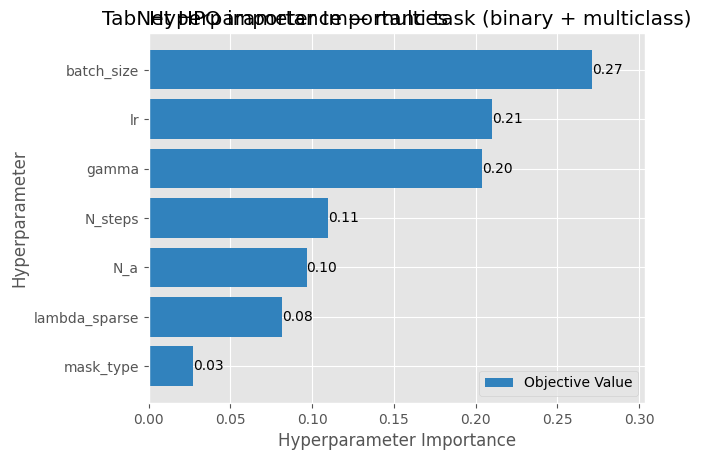

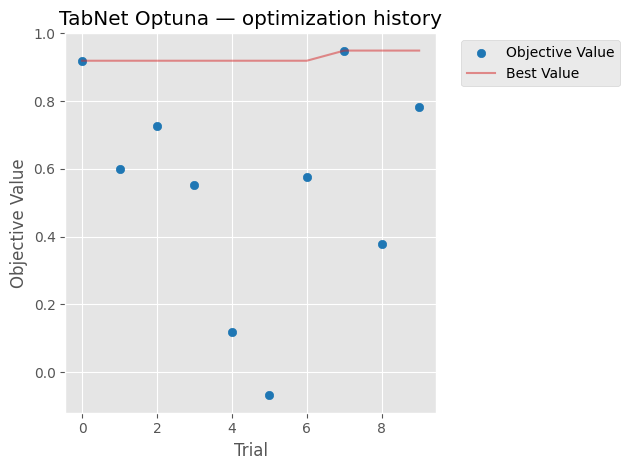

In [22]:
# ── Optuna — hyperparameter importance ────────────────────────────────
fig = optuna.visualization.matplotlib.plot_param_importances(study_tabnet)
plt.title('TabNet HPO importance — multi-task (binary + multiclass)')
plt.savefig(f'{PATH_IMG}/optuna_tabnet_multitask.png', dpi=150, bbox_inches='tight')
plt.show()

fig = optuna.visualization.matplotlib.plot_optimization_history(study_tabnet)
plt.title('TabNet Optuna — optimization history')
plt.savefig(f'{PATH_IMG}/optuna_tabnet_history.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 1b — TFT: Temporal Fusion Transformer (Time Series)

**Strategy: Single Continuous Time Series**

The entire dataset represents a **single continuous network capture session** ordered by `Timestamp`.
Flows are sorted chronologically and indexed sequentially to form a unified time series.
This allows TFT to learn temporal patterns in attack campaigns (port scans, DDoS bursts, etc.)
by looking at the sequence of flows over time.

Each trial's model, confusion matrices (when computable), and metrics are saved in memory.

In [23]:
# ── Global storage for TFT trial artifacts ────────────────────────────
tft_trial_artifacts = {}

In [24]:
class LossHistoryCallback(pl.Callback):
    def __init__(self):
        self.val_losses = []
    def on_validation_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get('val_loss')
        if loss is not None:
            self.val_losses.append(loss.item())

In [25]:
def tft_multitarget_objective(ts_train, ts_val, max_epochs,
                              batch_size, lr, hidden_size, attention_head_size, dropout, hidden_continuous,
                              verbose=0, trial=None, label_model=None):

    FINAL_LABEL = label_model if label_model is not None else trial.number

    # ── Dataloaders — num_workers>0 per parallelizzare il caricamento ─
    _dl_workers = min(8, os.cpu_count() or 0)
    train_dl = ts_train.to_dataloader(train=True, batch_size=batch_size, num_workers=_dl_workers)

    # ── Callbacks ─────────────────────────────────────────────────────
    loss_history = LossHistoryCallback()
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, mode='min'),
        loss_history,
    ]
    if trial is not None:
        callbacks.append(PyTorchLightningPruningCallback(trial, monitor='val_loss'))

    _norms = ts_train.target_normalizer.normalizers
    _n_out = [len(n.classes_) for n in _norms]

    tft = TemporalFusionTransformer.from_dataset(
        ts_train,
        learning_rate            = lr,
        hidden_size              = hidden_size,
        attention_head_size      = attention_head_size,
        dropout                  = dropout,
        hidden_continuous_size   = hidden_continuous,
        output_size              = _n_out,
        loss                     = MultiLoss([CrossEntropy(), CrossEntropy()]),
        log_interval             = -1 if verbose == 0 else 10,
        reduce_on_plateau_patience = 3,
    )

    bool_verbose = verbose != 0
    trainer = pl.Trainer(
        max_epochs           = max_epochs,
        accelerator          = 'auto',
        enable_progress_bar  = bool_verbose,
        enable_model_summary = bool_verbose,
        callbacks            = callbacks,
        logger               = bool_verbose,
        check_val_every_n_epoch = 1,
        gradient_clip_val    = 0.5,       # ← stabilizza convergenza
        precision            = '16-mixed', # ← mixed precision per velocità
    )

    # ── Variabili di risultato — inizializzate a None ──────────────────
    cm_bin, cm_mul = None, None
    actuals_bin, actuals_mul = None, None
    pred_bin, pred_mul = None, None
    raw_preds = None
    metrics_first_output, metrics_second_output = None, None
    feature_importance = None
    val_loss = float('inf')
    pruned = False
    model_path = f'models/tft_trial_{FINAL_LABEL}.ckpt'

    # ── Training — finally garantisce sempre il checkpoint ────────────
    try:
        trainer.fit(tft, train_dataloaders=train_dl,
                    val_dataloaders=ts_val.to_dataloader(train=False, batch_size=batch_size, num_workers=_dl_workers))
        val_loss = trainer.callback_metrics.get('val_loss', torch.tensor(float('inf'))).item()

    except optuna.exceptions.TrialPruned:
        val_loss = trainer.callback_metrics.get('val_loss', torch.tensor(float('inf'))).item()
        pruned = True
        print(f"  ✂️  Trial {FINAL_LABEL} pruned (val_loss so far: {val_loss:.4f})")

    finally:
        trainer.save_checkpoint(model_path)  # ← una sola volta, sempre

    # ── Feature importance — calcolata sempre (anche su trial potati) ──
    try:
        val_dl_fi   = ts_val.to_dataloader(train=False, batch_size=batch_size, num_workers=0)
        raw_preds_fi = tft.predict(val_dl_fi, mode='raw')
        interpretation = tft.interpret_output(raw_preds_fi, reduction='sum')
        enc_imp = interpretation['encoder_variables'].numpy()
        feature_names_tft = ts_train.reals + ts_train.categoricals
        feature_importance = dict(zip(feature_names_tft, enc_imp.tolist()))
    except Exception as e:
        print(f"  ⚠️ Feature importance unavailable (trial {FINAL_LABEL}): {e}")
        feature_importance = None

    # ── Evaluation completa — solo se non potato ───────────────────────
    if not pruned:
        try:
            val_dl_eval = ts_val.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

            actuals_bin_list, actuals_mul_list = [], []
            for x_batch, y_batch in val_dl_eval:
                y_targets = y_batch[0]
                actuals_bin_list.append(y_targets[0].reshape(-1))   # ← reshape, non squeeze
                actuals_mul_list.append(y_targets[1].reshape(-1))

            actuals_bin = torch.cat(actuals_bin_list).numpy().astype(int)
            actuals_mul = torch.cat(actuals_mul_list).numpy().astype(int)

            val_dl_pred = ts_val.to_dataloader(train=False, batch_size=batch_size, num_workers=0)
            raw_preds = tft.predict(val_dl_pred, mode='raw')

            # reshape invece di squeeze — robusto anche su batch_size=1
            pred_bin = raw_preds['prediction'][0].reshape(-1, raw_preds['prediction'][0].shape[-1]).argmax(dim=-1).numpy()
            pred_mul = raw_preds['prediction'][1].reshape(-1, raw_preds['prediction'][1].shape[-1]).argmax(dim=-1).numpy()

            # Tronca alla lunghezza minima — safety net su disallineamenti
            n = min(len(actuals_bin), len(pred_bin))
            actuals_bin, pred_bin = actuals_bin[:n], pred_bin[:n]
            actuals_mul, pred_mul = actuals_mul[:n], pred_mul[:n]

            proba_bin = raw_preds['prediction'][0].reshape(-1, raw_preds['prediction'][0].shape[-1]).numpy()[:n]
            proba_mul = raw_preds['prediction'][1].reshape(-1, raw_preds['prediction'][1].shape[-1]).numpy()[:n]

            cm_bin = confusion_matrix(actuals_bin, pred_bin)
            cm_mul = confusion_matrix(actuals_mul, pred_mul)

            _inv_bin = {v: k for k, v in ts_train.target_normalizer.normalizers[0].classes_.items()}
            _inv_mul = {v: k for k, v in ts_train.target_normalizer.normalizers[1].classes_.items()}
            _bin_cls = [str(_inv_bin.get(i, f'cls{i}')) for i in sorted(np.unique(np.concatenate([actuals_bin, pred_bin])))]
            _mul_cls = [str(_inv_mul.get(i, f'cls{i}')) for i in sorted(np.unique(np.concatenate([actuals_mul, pred_mul])))]

            metrics_first_output = print_metrics(
                actuals_bin, pred_bin, proba_bin,
                f'Trial {FINAL_LABEL} - Binary Task',
                class_names=_bin_cls, verbose=verbose)
            metrics_second_output = print_metrics(
                actuals_mul, pred_mul, proba_mul,
                f'Trial {FINAL_LABEL} - Multiclass Task',
                class_names=_mul_cls, verbose=verbose)

            # ── Diagnostic: distribuzione classi nella validazione ────
            print(f"  📊 Val samples: {n} | Binary classes: {np.unique(actuals_bin)} | Multi classes: {np.unique(actuals_mul)}")

            # ── Plot CM ───────────────────────────────────────────────
            if verbose != 0:
                fig, axes = plt.subplots(1, 2, figsize=(14, 5))
                sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                            xticklabels=_bin_cls, yticklabels=_bin_cls)
                axes[0].set_title(f'Trial {FINAL_LABEL} — Binary CM')
                axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
                sns.heatmap(cm_mul, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                            xticklabels=_mul_cls, yticklabels=_mul_cls)
                axes[1].set_title(f'Trial {FINAL_LABEL} — Multiclass CM')
                axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
                plt.xticks(rotation=45, ha='right')
                plt.tight_layout()
                plt.savefig(f'{PATH_IMG}/tft_trial{FINAL_LABEL}_cm.png', dpi=150, bbox_inches='tight')
                plt.show()

        except Exception as e:
            import traceback
            print(f"  ⚠️ TFT evaluation failed (trial {FINAL_LABEL}): {e}")
            traceback.print_exc()   # ← traceback completo per debug

    # ── Plot loss curve ────────────────────────────────────────────────
    if verbose != 0 and loss_history.val_losses:
        best_epoch = int(np.argmin(loss_history.val_losses))
        best_loss  = loss_history.val_losses[best_epoch]

        fig_loss, ax_loss = plt.subplots(figsize=(8, 4))
        ax_loss.plot(loss_history.val_losses, marker='o', markersize=3, linewidth=1.5, color='steelblue')
        ax_loss.axvline(x=len(loss_history.val_losses) - 1, color='gray', linestyle='--', alpha=0.5)
        ax_loss.scatter([best_epoch], [best_loss], color='red', zorder=5,
                        label=f'Best: epoch {best_epoch}, loss={best_loss:.4f}')
        ax_loss.set_xlabel('Epoch')
        ax_loss.set_ylabel('Val Loss')
        ax_loss.set_title(f'Trial {FINAL_LABEL} — Validation Loss Curve')
        ax_loss.legend()
        ax_loss.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{PATH_IMG}/tft_trial{FINAL_LABEL}_loss.png', dpi=150, bbox_inches='tight')
        plt.show()

        delta = abs(loss_history.val_losses[-1] - loss_history.val_losses[max(0, len(loss_history.val_losses) - 5)])
        print(f" Best epoch: {best_epoch}/{len(loss_history.val_losses)-1} "
              f"| Best val_loss: {best_loss:.4f} | Δ ultimi 5 epoch: {delta:.5f}")

    # ── Build & save artifact dict ─────────────────────────────────────
    hp = trial.params if trial is not None else {
        'hidden_size': hidden_size, 'attention_head_size': attention_head_size,
        'dropout': dropout, 'hidden_continuous': hidden_continuous,
        'lr': lr, 'batch_size': batch_size,
    }
    object_to_store = {
        'model':              model_path,
        'model_type':         'TFT',
        'label':              str(FINAL_LABEL),
        'pruned':             pruned,
        'feature_importance': feature_importance,
        'val_loss':           float(val_loss),
        'cm_bin':             cm_bin.tolist() if cm_bin is not None else None,
        'cm_mul':             cm_mul.tolist() if cm_mul is not None else None,
        'params':             hp,
        'metrics_binary':     metrics_first_output,
        'metrics_multiclass': metrics_second_output,
    }
    tft_trial_artifacts[FINAL_LABEL] = {**object_to_store, '_live_model': tft, '_trainer': trainer}

    with open(f'models/tft_trial_{FINAL_LABEL}_artifacts.json', 'w') as f:
        json.dump(object_to_store, f, indent=4, default=json_serializer)

    status = "✂️ pruned" if pruned else "✅"
    print(f"  {status} Trial {FINAL_LABEL}: val_loss={val_loss:.4f}")
    print(f"  💾  Saved: tft_trial_{FINAL_LABEL}_artifacts.json")

    # Re-raise per Optuna — deve sapere che il trial è stato potato
    if pruned:
        raise optuna.exceptions.TrialPruned()

    return val_loss

#### 1b.1 edit dataset

In [26]:
# ── Build time-indexed dataframe for TFT ─────────────────────────────
pdf_tft = pdf_encoded.copy()

# ── 1. Single continuous time series ─────────────────────────────────
# The entire dataset is one unified network capture session.
# All flows form a single time series ordered by Timestamp.
pdf_tft['series_id'] = '0'
print("✅  Single time series (series_id = '0')")

# ── 2. Create time index from Timestamp ──────────────────────────────
if 'Timestamp' in pdf_tft.columns:
    pdf_tft['Timestamp'] = pd.to_datetime(pdf_tft['Timestamp'], errors='coerce')
    pdf_tft = pdf_tft.sort_values('Timestamp').reset_index(drop=True)
    pdf_tft['time_idx'] = np.arange(len(pdf_tft))
    print("✅  time_idx created from Timestamp ordering")
else:
    pdf_tft = pdf_tft.reset_index(drop=True)
    pdf_tft['time_idx'] = np.arange(len(pdf_tft))
    print("⚠️  No Timestamp column — using row order as time_idx")

# ── 3. Configuration ────────────────────────────────────────────────
MIN_SEQ_LEN     = 10
MAX_PRED_LEN    = 1        # predict 1 step ahead (the label of the next flow)
MAX_ENCODER_LEN = 30       # look-back window

n_rows = len(pdf_tft)
assert n_rows >= MIN_SEQ_LEN, f"Dataset has only {n_rows} rows, need ≥ {MIN_SEQ_LEN}"
print(f"Total rows: {n_rows:,} | Encoder window: {MAX_ENCODER_LEN} | Prediction steps: {MAX_PRED_LEN}")

✅  Single time series (series_id = '0')
✅  time_idx created from Timestamp ordering
Total rows: 16,191 | Encoder window: 30 | Prediction steps: 1


In [27]:
# ── TFT TimeSeriesDataSet — multi-target (both labels together) ───────
#
# TFT supports multiple simultaneous targets natively:
#   target=['label_generic_enc', 'Label_enc']
#   output_size=[2, n_classes_multi]
#   loss=MultiLoss([CrossEntropy(), CrossEntropy()])
#
# The Variable Selection Network is shared → one importance map for both.

from pytorch_forecasting.data import NaNLabelEncoder, MultiNormalizer

def make_tft_datasets(pdf,
                      max_encoder_len=MAX_ENCODER_LEN,
                      max_pred_len=MAX_PRED_LEN,
                      val_frac=0.2):
    """Build train/val TimeSeriesDataSet with dual target for TFT."""
    pdf = pdf.copy()
    pdf['label_generic_enc'] = pdf['label_generic_enc'].astype(float)
    pdf['Label_enc']         = pdf['Label_enc'].astype(float)

    max_time = pdf['time_idx'].max()
    cutoff   = int(max_time * (1 - val_frac))

    common_kwargs = dict(
        time_idx              = 'time_idx',
        target                = ['label_generic_enc', 'Label_enc'],   # ← dual target
        group_ids             = ['series_id'],
        max_encoder_length    = max_encoder_len,
        max_prediction_length = max_pred_len,
        time_varying_known_reals   = [],
        time_varying_unknown_reals = [f for f in FINAL_FEATURES if f in pdf.columns],
        target_normalizer     = MultiNormalizer([
            NaNLabelEncoder(add_nan=False),   # add_nan=True: handles unseen val classes (time split)
            NaNLabelEncoder(add_nan=True),   # class 0 = NaN/unknown, real classes start at 1
        ]),
        add_relative_time_idx = True,
        add_target_scales     = False,
        add_encoder_length    = True,
    )

    ts_train = TimeSeriesDataSet(
        pdf[lambda d: d['time_idx'] <= cutoff],
        **common_kwargs
    )

    # ── FIX: predict=False per avere TUTTI i campioni di validazione ──
    ts_val = TimeSeriesDataSet.from_dataset(
        ts_train,
        pdf[lambda d: d['time_idx'] > cutoff - max_encoder_len],
        predict=False,
        stop_randomization=True,
    )

    print(f"   Train samples: {len(ts_train):,} | Val samples: {len(ts_val):,}")

    return ts_train, ts_val

# ── Clean inf / extreme values in pdf_tft before building TFT datasets ─
tft_real_cols = [f for f in FINAL_FEATURES if f in pdf_tft.columns]
for _c in tft_real_cols:
    pdf_tft[_c] = pd.to_numeric(pdf_tft[_c], errors='coerce')
pdf_tft[tft_real_cols] = pdf_tft[tft_real_cols].fillna(0.0)
pdf_tft[tft_real_cols] = pdf_tft[tft_real_cols].replace([np.inf, -np.inf], 0.0)

# Clip to float32 range to avoid overflow
_f32_max = np.finfo(np.float32).max
pdf_tft[tft_real_cols] = pdf_tft[tft_real_cols].clip(-_f32_max, _f32_max)

_n_inf = np.isinf(pdf_tft[tft_real_cols].values).sum()
_n_nan = np.isnan(pdf_tft[tft_real_cols].values).sum()
print(f"✅  pdf_tft cleaned: remaining inf={_n_inf}, nan={_n_nan}")

print("Building TFT multi-target datasets ...")
ts_train, ts_val = make_tft_datasets(pdf_tft)
print("✅  TFT datasets ready")
print(f"   Targets: {ts_train.target_names}")

✅  pdf_tft cleaned: remaining inf=0, nan=0
Building TFT multi-target datasets ...
   Train samples: 12,923 | Val samples: 3,238
✅  TFT datasets ready
   Targets: ['label_generic_enc', 'Label_enc']


#### 1b.2 Training TFT

In [28]:
def study_tft_multitarget(trial, ts_train, ts_val):
    """Optuna objective for TFT multi-target."""
    
    hidden_size         = trial.suggest_categorical('hidden_size',       [16, 32, 64, 128])
    attention_head_size = trial.suggest_int('attention_head_size',        1, 4)
    dropout             = trial.suggest_float('dropout',                  0.1, 0.4, step=0.05)
    hidden_continuous   = trial.suggest_categorical('hidden_continuous',  [8, 16, 32])
    lr                  = trial.suggest_float('lr',                       1e-4, 1e-2, log=True)
    batch_size          = trial.suggest_categorical('batch_size',         [64, 128, 256])

    val_loss = tft_multitarget_objective(ts_train, ts_val, TFT_MAX_EPOCHS,
                              batch_size, lr, hidden_size, attention_head_size, dropout, hidden_continuous, trial=trial)

    return val_loss

In [ ]:
# ── Tune TFT — single multi-target study ─────────────────────────────
print("🔍  Tuning TFT (binary + multiclass simultaneously) ...")

study_tft = optuna.create_study(
    direction  = 'minimize',
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_SEED),
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials = 5,
        n_warmup_steps   = 12,  # ← basato sul tuo grafico
        interval_steps   = 1,
    ),
    study_name = 'tft_multitarget'
)

study_tft.optimize(
    lambda t: study_tft_multitarget(t, ts_train, ts_val),
    n_trials         = N_OPTUNA_TRIALS,
    timeout          = 7200,
    show_progress_bar= True
)

best_tft = study_tft.best_params
print(f"\n✅  Best val_loss (multi-target) is from trial {study_tft.best_trial.number} : {study_tft.best_value:.4f}")
print(f"Best params: {best_tft}")

# ── Summary of all TFT trials → CSV ──────────────────────────────────
#tft_trials_df = pd.DataFrame([
#    {'trial': t, **art['params'], 'val_loss': art['val_loss']}
#    for t, art in tft_trial_artifacts.items()
#]).sort_values('val_loss', ascending=True)

#tft_trials_df.to_csv('models/tft_all_trials.csv', index=False)
#print(f"\n💾  Saved {len(tft_trial_artifacts)} TFT trial results → models/tft_all_trials.csv")
#print(tft_trials_df.to_string(index=False))

🔍  Tuning TFT (binary + multiclass simultaneously) ...


  0%|          | 0/10 [00:00<?, ?it/s]Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`weights_only` was not set, defaulting to `False`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning,

  ⚠️ TFT evaluation failed (trial 0): Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].
  ✅ Trial 0: val_loss=2.2308
  💾  Saved: tft_trial_0_artifacts.json


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`weights_only` was not set, defaulting to `False`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://py

  📊 Val samples: 3238 | Binary classes: [0 1] | Multi classes: [0 1]
  ✅ Trial 1: val_loss=2.3182
  💾  Saved: tft_trial_1_artifacts.json


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


In [ ]:
# ── TFT — Optuna visualisation ────────────────────────────────────────
fig = optuna.visualization.matplotlib.plot_param_importances(study_tft)
plt.title('TFT HPO importance — multi-target')
plt.savefig(f'{PATH_IMG}/optuna_tft_multitarget.png', dpi=150, bbox_inches='tight')
plt.show()

fig = optuna.visualization.matplotlib.plot_optimization_history(study_tft)
plt.title('TFT Optuna — optimization history')
plt.savefig(f'{PATH_IMG}/optuna_tft_history.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save all best hyperparameters (JSON + CSV) ───────────────────────
all_best_params = {
    'tabnet_multitask': best_tabnet,
    'tft_multitarget':  best_tft,
}

with open('models/best_hyperparams.json', 'w') as f:
    json.dump(all_best_params, f, indent=2)

rows_csv = []
for model_name, params in all_best_params.items():
    rows_csv.append({'model': model_name, **params})
pd.DataFrame(rows_csv).to_csv('models/best_hyperparams.csv', index=False)

print("💾  Saved: models/best_hyperparams.json + models/best_hyperparams.csv")
print(json.dumps(all_best_params, indent=2))

print(f"\n✅  Step 1 complete.")
print(f"    Best TabNet mean MCC: {study_tabnet.best_value:.4f}")
print(f"    Best TFT val_loss:    {study_tft.best_value:.4f}")

## Step 2: Extract Best Models & Feature Importance

From all Optuna trials, extract the best model for each type:
- **TabNet:** trial with highest mean MCC (binary + multiclass)
- **TFT:** trial with lowest validation loss

Plot feature importance for both models.

In [ ]:
# ── Step 2: Extract best models from stored artifacts ─────────────────

# TabNet: best trial (highest mean MCC)
best_tabnet_trial_num = study_tabnet.best_trial.number
best_tabnet_art = tabnet_trial_artifacts[best_tabnet_trial_num]
best_tabnet_model = best_tabnet_art['_live_model']  # oggetto in RAM
print(f"✅  Best TabNet model: trial {best_tabnet_trial_num} "
      f"(mean MCC={best_tabnet_art['mean_mcc']:.4f})")

# TFT: best trial (lowest val_loss)
best_tft_trial_num = study_tft.best_trial.number
best_tft_art = tft_trial_artifacts[best_tft_trial_num]
best_tft_model = best_tft_art['_live_model']  # oggetto in RAM
print(f"✅  Best TFT model: trial {best_tft_trial_num} "
      f"(val_loss={best_tft_art['val_loss']:.4f})")

# ── Copy best models to canonical path ───────────────────────────────
import shutil

# TabNet: già salvato come .zip durante il trial, basta copiarlo
shutil.copy(f'models/tabnet_trial_{best_tabnet_trial_num}.zip',
            'models/tabnet_multitask_best.zip')
print("💾  Saved: models/tabnet_multitask_best.zip")

# TFT: già salvato come .ckpt durante il trial, basta copiarlo
shutil.copy(f'models/tft_trial_{best_tft_trial_num}.ckpt',
            'models/tft_multitask_best.ckpt')
print("💾  Saved: models/tft_multitask_best.ckpt")

# ── Report sui best trial (validation) ───────────────────────────────
show_model_report(best_tabnet_trial_num, artifacts_dict=tabnet_trial_artifacts)
show_model_report(best_tft_trial_num,    artifacts_dict=tft_trial_artifacts)

In [ ]:
# ── Feature Importance: TabNet ────────────────────────────────────────
def plot_tabnet_importance(model, feature_names, top_n=20, filename=None):
    importances = model.feature_importances_
    fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, top_n * 0.4))
    sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis', ax=ax)
    ax.set_title('TabNet — Global Feature Importance (shared encoder, both tasks)',
                 fontsize=13)
    ax.set_xlabel('Attention-based importance')
    plt.tight_layout()
    if filename:
        plt.savefig(f'{PATH_IMG}/{filename}', dpi=150)
    plt.show()
    return fi_df

fi_tabnet = plot_tabnet_importance(
    best_tabnet_model, FINAL_FEATURES,
    filename='tabnet_fi_multitask.png'
)

# ── Feature Importance: TFT (Variable Selection Networks) ────────────
def plot_tft_importance(tft_model, ts_val, top_n=20, filename=None):
    val_dl = ts_val.to_dataloader(train=False, batch_size=256, num_workers=0)
    out = tft_model.predict(val_dl, mode='raw', return_x=True)
    # predict(return_x=True) can return 2 or 3 values depending on version
    raw_preds = out[0] if isinstance(out, (tuple, list)) else out
    interpretation = tft_model.interpret_output(raw_preds, reduction='sum')

    encoder_vars = tft_model.encoder_variables
    enc_weights  = interpretation['encoder_variables'].numpy()

    fi_df = pd.DataFrame({'feature': encoder_vars, 'importance': enc_weights})
    fi_df = fi_df.sort_values('importance', ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, top_n * 0.45))
    sns.barplot(data=fi_df, x='importance', y='feature', palette='magma', ax=ax)
    ax.set_title('TFT — Variable Selection Weights (shared encoder, both targets)',
                 fontsize=13)
    ax.set_xlabel('Selection weight (sum over val set)')
    plt.tight_layout()
    if filename:
        plt.savefig(f'{PATH_IMG}/{filename}', dpi=150)
    plt.show()
    return fi_df

fi_tft = plot_tft_importance(
    best_tft_model, ts_val,
    filename='tft_fi_multitarget.png'
)

# ── Side-by-side comparison ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10_tabnet = fi_tabnet.head(10).set_index('feature')['importance']
top10_tft    = fi_tft.head(10).set_index('feature')['importance']

top10_tabnet.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('TabNet — Top 10 Features', fontsize=12)
axes[0].invert_yaxis()

top10_tft.plot.barh(ax=axes[1], color='darkorange')
axes[1].set_title('TFT — Top 10 Features', fontsize=12)
axes[1].invert_yaxis()

plt.suptitle('Step 2: Feature Importance Comparison (TabNet vs TFT)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PATH_IMG}/fi_comparison_step2.png', dpi=150)
plt.show()

print("✅  Step 2 complete.")

## Step 3: Top Feature Intersection

Take the **top 10 features** from each model (TabNet + TFT) and compute their **intersection**.  
This gives the ~8–10 features that *both* models consider most important.  
If the intersection is too small (< 5), we fall back to a combined ranking.

In [ ]:
# ── Step 3: Top 10 Features — Intersection ────────────────────────────
top10_tabnet_features = set(fi_tabnet.head(10)['feature'].tolist())
top10_tft_features    = set(fi_tft.head(10)['feature'].tolist())

# Intersection
IMPORTANT_FEATURES = sorted(top10_tabnet_features & top10_tft_features)

print(f"📊  TabNet top 10: {sorted(top10_tabnet_features)}")
print(f"📊  TFT top 10:    {sorted(top10_tft_features)}")
print(f"\n🔗  Intersection ({len(IMPORTANT_FEATURES)} features):")
for f in IMPORTANT_FEATURES:
    print(f"    • {f}")

# If intersection is too small, fall back to combined importance ranking
if len(IMPORTANT_FEATURES) < 5:
    print(f"\n⚠️  Intersection too small ({len(IMPORTANT_FEATURES)}). "
          f"Using combined importance ranking instead.")

    # Normalize importances [0, 1] and sum across models
    fi_tab_norm = fi_tabnet.copy()
    fi_tab_norm['importance'] = fi_tab_norm['importance'] / fi_tab_norm['importance'].sum()
    fi_tft_norm = fi_tft.copy()
    fi_tft_norm['importance'] = fi_tft_norm['importance'] / fi_tft_norm['importance'].sum()

    fi_combined = (
        fi_tab_norm.set_index('feature')['importance']
        .add(fi_tft_norm.set_index('feature')['importance'], fill_value=0)
        .sort_values(ascending=False)
    )
    IMPORTANT_FEATURES = fi_combined.head(10).index.tolist()
    print(f"📊  Combined top {len(IMPORTANT_FEATURES)} features: {IMPORTANT_FEATURES}")

# Save feature list
pd.DataFrame({'feature': IMPORTANT_FEATURES}).to_csv(
    'models/important_features.csv', index=False)
print(f"\n💾  Saved: models/important_features.csv ({len(IMPORTANT_FEATURES)} features)")
print(f"\n✅  Step 3 complete: {len(IMPORTANT_FEATURES)} important features selected.")

## Step 4: 10% Dataset with Important Features Only

Reload the original dataset → stratified 10% sample (preserving class distribution)  
→ keep **only the important features** from Step 3 → save in memory.

In [ ]:
# ── Step 4: 10% Stratified Dataset with Important Features Only ───────
print("📦  Loading original dataset and sampling 10% stratified ...")

# Reload full dataset from Spark (or reuse sdf_full if still in memory)
try:
    sdf_full_reload = sdf_full
    print("   (reusing sdf_full from memory)")
except NameError:
    sdf_full_reload = spark.read.parquet(f'{PATH}/all_elaborated.parquet')
    print("   (reloaded from parquet)")

# 10% stratified sample by label_generic
fractions_10pct = {
    row['label_generic']: 0.10
    for row in sdf_full_reload.select('label_generic').distinct().collect()
}
sdf_10pct = sdf_full_reload.sampleBy('label_generic', fractions=fractions_10pct, seed=RANDOM_SEED)
print(f"📦  10% stratified sample → {sdf_10pct.count():,} rows")
FEATURE_NAMES = list(sdf_10pct.columns)

# Encode labels
sdf_10pct_enc, label_classes_10 = label_encoding_spark(sdf_10pct)

# Convert to Pandas
pdf_10pct, cat_encoders_10, cat_dims_10 = preprocess_to_pandas(
    sdf_10pct_enc, CONTINUOUS_FEATURES, CATEGORICAL_FEATURES, BINARY_FEATURES
)

# ── Keep only important features + targets ────────────────────────────
BASELINE_FEATURES = [f for f in IMPORTANT_FEATURES if f in pdf_10pct.columns]
missing_feat = [f for f in IMPORTANT_FEATURES if f not in pdf_10pct.columns]
if missing_feat:
    print(f"⚠️  Missing features in 10% dataset: {missing_feat}")

keep_cols = BASELINE_FEATURES + ['Label', 'label_generic', 'Label_enc', 'label_generic_enc']
if 'Timestamp' in pdf_10pct.columns:
    keep_cols.append('Timestamp')

pdf_baseline = pdf_10pct[[c for c in keep_cols if c in pdf_10pct.columns]].copy()

print(f"\n✅  Baseline dataset: {len(pdf_baseline):,} rows × {len(BASELINE_FEATURES)} features")
print(f"    Features: {BASELINE_FEATURES}")

# ── Save baseline dataset ────────────────────────────────────────────
BASELINE_PATH = f'{PATH}/baseline_10pct_top_features.parquet'
pdf_baseline.to_parquet(BASELINE_PATH, index=False)
print(f"💾  Saved: {BASELINE_PATH}")
print(f"\n✅  Step 4 complete.")

## Step 5: Baseline Model Training

Retrain **new instances** of TabNet and TFT on the 10% reduced-feature dataset,  
using the **optimized hyperparameters from Step 1**.

These models are the **baseline** for subsequent noise-fragility experiments.

### 5.1. train test split

In [ ]:
# ── Step 5a: Prepare baseline arrays ──────────────────────────────────
X_base = pdf_baseline[BASELINE_FEATURES].values.astype(np.float64)
y_base_bin = pdf_baseline['label_generic_enc'].values.astype(int)
y_base_mul = pdf_baseline['Label_enc'].values.astype(int)

# Clean inf / NaN
X_base = np.nan_to_num(X_base, nan=0.0, posinf=0.0, neginf=0.0)
_f32_max = np.finfo(np.float32).max
X_base = np.clip(X_base, -_f32_max, _f32_max).astype(np.float32)

# Filter rare classes
classes_base, counts_base = np.unique(y_base_mul, return_counts=True)
rare_base = classes_base[counts_base < MIN_SAMPLES_PER_CLASS]
if len(rare_base) > 0:
    keep_mask_base = ~np.isin(y_base_mul, rare_base)
    X_base = X_base[keep_mask_base]
    y_base_bin = y_base_bin[keep_mask_base]
    y_base_mul = y_base_mul[keep_mask_base]
    print(f"⚠️  Dropped {len(rare_base)} rare classes from baseline dataset")
else:
    print("✅  All classes have enough samples in baseline dataset")

n_classes_baseline = len(np.unique(y_base_mul))
y_base_combined = np.column_stack([y_base_bin, y_base_mul])

# Single stratified split (same strategy as Step 1)
X_base_tr, X_base_te, y_base_tr, y_base_te = train_test_split(
    X_base, y_base_combined, test_size=TEST_SIZE,
    random_state=RANDOM_SEED, stratify=y_base_bin
)
X_base_train, X_base_val, y_base_train, y_base_val = train_test_split(
    X_base_tr, y_base_tr, test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED, stratify=y_base_tr[:, 0]
)

y_base_tr_bin,  y_base_tr_mul  = y_base_train[:, 0], y_base_train[:, 1]
y_base_val_bin, y_base_val_mul = y_base_val[:, 0],   y_base_val[:, 1]
y_base_te_bin,  y_base_te_mul  = y_base_te[:, 0],    y_base_te[:, 1]

# Scale continuous features (fit on train only)
base_cont_idxs = [BASELINE_FEATURES.index(c) for c in CONTINUOUS_FEATURES
                  if c in BASELINE_FEATURES]
if base_cont_idxs:
    scaler_base = StandardScaler()
    scaler_base.fit(X_base_train[:, base_cont_idxs])
    for arr in [X_base_train, X_base_val, X_base_te]:
        arr[:, base_cont_idxs] = scaler_base.transform(arr[:, base_cont_idxs])
    print(f"Scaled {len(base_cont_idxs)} continuous features")

# Categorical metadata for baseline features
BASE_CAT_FEATURES = [c for c in CATEGORICAL_FEATURES if c in BASELINE_FEATURES]
BASE_CAT_IDXS = [BASELINE_FEATURES.index(c) for c in BASE_CAT_FEATURES]
BASE_CAT_DIMS = [int(pdf_baseline[c].nunique()) for c in BASE_CAT_FEATURES]F1: 0.958

print(f"\n✅  Baseline splits ready:")
print(f"    Train: {len(X_base_train):,} | Val: {len(X_base_val):,} | Test: {len(X_base_te):,}")
print(f"    Features: {len(BASELINE_FEATURES)} | Binary: 2 | Multi: {n_classes_baseline}")
if BASE_CAT_IDXS:
    print(f"    Categorical: {list(zip(BASE_CAT_FEATURES, BASE_CAT_IDXS, BASE_CAT_DIMS))}")

### 5.2. baseline evaluation

In [ ]:
# ── Step 5b: Retrain TabNet Baseline ──────────────────────────────────
print("🏋️  Training TabNet baseline (optimized HP, 10% data, top features) ...")

tabnet_multitask_objective(
    X_base_train, X_base_val,
    y_base_tr_bin, y_base_tr_mul,
    y_base_val_bin, y_base_val_mul,
    best_tabnet['N_a'], best_tabnet['N_steps'], best_tabnet['gamma'], (best_tabnet['lambda_sparse']*((0.001 / 0.10) ** 0.5 )),
    best_tabnet['lr'], best_tabnet['batch_size']*10, best_tabnet['mask_type'],
    verbose=1, trial=None, label_model='Baseline',
    feature_names=FEATURE_NAMES
)

In [ ]:
# ── Step 5c: Retrain TFT Baseline ─────────────────────────────────────
print("🏋️  Training TFT baseline (optimized HP, 10% data, top features) ...")

# Build TFT dataframe for baseline dataset
pdf_tft_base = pdf_baseline.copy()
pdf_tft_base['series_id'] = '0'

if 'Timestamp' in pdf_tft_base.columns:
    pdf_tft_base['Timestamp'] = pd.to_datetime(pdf_tft_base['Timestamp'], errors='coerce')
    pdf_tft_base = pdf_tft_base.sort_values('Timestamp').reset_index(drop=True)

pdf_tft_base['time_idx'] = np.arange(len(pdf_tft_base))

# Clean values
base_real_cols = [f for f in BASELINE_FEATURES if f in pdf_tft_base.columns]
for _c in base_real_cols:
    pdf_tft_base[_c] = pd.to_numeric(pdf_tft_base[_c], errors='coerce')
pdf_tft_base[base_real_cols] = pdf_tft_base[base_real_cols].fillna(0.0)
pdf_tft_base[base_real_cols] = pdf_tft_base[base_real_cols].replace([np.inf, -np.inf], 0.0)
pdf_tft_base[base_real_cols] = pdf_tft_base[base_real_cols].clip(-_f32_max, _f32_max)

# Targets as float for TFT
pdf_tft_base['label_generic_enc'] = pdf_tft_base['label_generic_enc'].astype(float)
pdf_tft_base['Label_enc']         = pdf_tft_base['Label_enc'].astype(float)

# Build TFT TimeSeriesDataSets for baseline
max_time_base = pdf_tft_base['time_idx'].max()
cutoff_base   = int(max_time_base * 0.8)

n_classes_base_tft = int(pdf_tft_base['Label_enc'].nunique())

base_common_kwargs = dict(
    time_idx              = 'time_idx',
    target                = ['label_generic_enc', 'Label_enc'],
    group_ids             = ['series_id'],
    max_encoder_length    = MAX_ENCODER_LEN,
    max_prediction_length = MAX_PRED_LEN,
    time_varying_known_reals   = [],
    time_varying_unknown_reals = base_real_cols,
    target_normalizer     = MultiNormalizer([
        NaNLabelEncoder(add_nan=True),
        NaNLabelEncoder(add_nan=True),
    ]),
    add_relative_time_idx = True,
    add_target_scales     = False,
    add_encoder_length    = True,
)

ts_base_train = TimeSeriesDataSet(
    pdf_tft_base[lambda d: d['time_idx'] <= cutoff_base],
    **base_common_kwargs
)
ts_base_val = TimeSeriesDataSet.from_dataset(
    ts_base_train,
    pdf_tft_base[lambda d: d['time_idx'] > cutoff_base - MAX_ENCODER_LEN],
    predict=True
)

# Train TFT baseline — riusa la stessa funzione con verbose=1 e trial=None
tft_multitarget_objective(
    ts_base_train, ts_base_val,
    max_epochs=TFT_MAX_EPOCHS * 2,
    batch_size=best_tft['batch_size']*10,
    lr=best_tft['lr'],
    hidden_size=best_tft['hidden_size'],
    attention_head_size=best_tft['attention_head_size'],
    dropout=best_tft['dropout'],
    hidden_continuous=best_tft['hidden_continuous'],
    verbose=1,
    trial=None,
    label_model='TFT_Baseline'
)

print("✅  TFT Baseline stored in tft_trial_artifacts['TFT_Baseline']")